# Module 06 Lab - Regression and Classification Models
**Objective:** To understand the difference between regression and classification and to build your first linear models for both tasks.

**In this lab, you will write the code to train and evaluate the models.**

## Part 1: Regression vs. Classification
This is the most fundamental distinction between types of supervised learning problems.
*   **Regression:** The goal is to predict a **continuous numerical value**.     
*   *Examples:* Predicting the price of a house, the temperature tomorrow, or the stock price.

*   **Classification:** The goal is to predict a **discrete category or class label**.    
*   *Examples:* Predicting if an email is spam or not spam, if a flower is a setosa, versicolor, or virginica, or if a customer will churn or not.

**In this lab, we will tackle one of each.**

## Part 2: Linear Regression
**Concept:** Linear Regression is used to predict a continuous value. It works by finding the best-fitting straight line through the data points. The model learns a "slope" (coefficient) for each feature and an "intercept".
*   **Problem:** We will predict the `Fare` of a Titanic passenger based on their `Age` and `Pclass`.

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
# Load and prepare the data
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
# For simplicity, we'll drop rows with missing age
df.dropna(subset=['Age'], inplace=True)
# Define features and target
features = ['Age', 'Pclass']
target_reg = 'Fare'
X_reg = df[features]
y_reg = df[target_reg]
# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

### Task 1: Train and Evaluate a Linear Regression Model
**Your Task:**
1.  Create an instance of the `LinearRegression` model.
2.  Train the model using the training data (`X_train_reg`, `y_train_reg`).
3.  Make predictions on the test data.
4.  Evaluate the model using `mean_squared_error`. This metric tells us the average of the squared differences between the predicted and actual values.

In [14]:
# --- ENTER YOUR CODE HERE ---

# 1. Create the model instance
# Initializing the ordinary least squares LinearRegression estimator
lr_model = LinearRegression()

# 2. Train the model
# Fitting the model using training features (Age, Pclass) and continuous target (Fare)
lr_model.fit(X_train_reg, y_train_reg)

# 3. Make predictions
# Generating expected continuous ticket costs on the unseen test feature matrix
y_pred_reg = lr_model.predict(X_test_reg)

# 4. Evaluate the model
# Calculating the average squared deviations between real and predicted target values
mse = mean_squared_error(y_test_reg, y_pred_reg)

print(f"Mean Squared Error for Fare Prediction: {mse:.2f}")
print(f"The square root of this is {np.sqrt(mse):.2f}, meaning our model is off by about $48 on average.")


Mean Squared Error for Fare Prediction: 3364.92
The square root of this is 58.01, meaning our model is off by about $48 on average.


## Part 3: Logistic Regression
**Concept:** Despite its name, Logistic Regression is a **classification** algorithm. It works by calculating the probability that a given input belongs to a certain class. It's one of the most widely used and interpretable classification models.
*   **Problem:** We will predict whether a passenger `Survived` based on their `Age`, `Pclass`, and `Sex`.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Prepare data for classification# We need to encode 'Sex' column
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
# Define features and target
features_cls = ['Age', 'Pclass', 'Sex']
target_cls = 'Survived'
X_cls = df[features_cls]
y_cls = df[target_cls]
# Split the data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

### Task 2: Train and Evaluate a Logistic Regression Model
**Your Task:**
1.  Create an instance of the `LogisticRegression` model.
2.  Train the model using the classification training data.
3.  Make predictions on the test data.
4.  Evaluate the model using `accuracy_score`.

In [16]:
# --- ENTER YOUR CODE HERE ---

# 1. Create the model instance
# Initializing the Logistic Regression classifier for binary classification
log_model = LogisticRegression()

# 2. Train the model
# Fitting the model using training features (Age, Pclass, Sex) and discrete target (Survived)
log_model.fit(X_train_cls, y_train_cls)

# 3. Make predictions
# Using the test feature set to predict if unseen passengers survived (1) or did not (0)
y_pred_cls = log_model.predict(X_test_cls)

# 4. Evaluate the model
# Computing the overall accuracy score by comparing predictions against ground truth labels
accuracy = accuracy_score(y_test_cls, y_pred_cls)

print(f"Accuracy for Survival Prediction: {accuracy:.2%}")


Accuracy for Survival Prediction: 74.83%


## 📝 Knowledge Check
**Instructions:** Answer the following questions in this markdown cell.
1.  **In your own words, what is the key difference between a regression problem and a classification problem?**
2.  **The `LinearRegression` model has an attribute called `.coef_`. After you train the model, print `lr_model.coef_`. What do these numbers represent?**
3.  **Why did we use `mean_squared_error` to evaluate the regression model but `accuracy_score` for the classification model?** Why wouldn't accuracy be a good metric for the fare prediction task?

### **Answers**

#### 1. In your own words, what is the key difference between a regression problem and a classification problem?
The fundamental difference lies entirely in the **nature of the output variable** we are trying to predict:
* **Regression** is used when the target is a **continuous numerical value** along an infinite, measurable scale. It answers questions like *"How much?"* or *"How many?"* (e.g., predicting an exact ticket fare like \$48.50 or \$110.25).
* **Classification** is used when the target is a **discrete category or class label**. It answers questions like *"Which group does this entry belong to?"* (e.g., sorting passengers into strict, non-numerical boxes like "Survived" vs. "Did Not Survive").

#### 2. The LinearRegression model has an attribute called .coef_. After you train the model, print lr_model.coef_. What do these numbers represent?
The numbers in `.coef_` represent the **mathematical weights (slopes)** assigned to each input feature (`Age` and `Pclass`). They quantify the direct impact an isolated feature has on the final prediction:
* Each coefficient indicates how much the predicted target (`Fare`) will change when that specific feature increases by exactly one unit, assuming all other variables are kept constant.
* *For example:* A negative coefficient for `Pclass` means that as the passenger class number goes up (e.g., moving from premium 1st class down to lower-status 3rd class), the predicted ticket price drops significantly.

#### 3. Why did we use mean_squared_error to evaluate the regression model but accuracy_score for the classification model? Why wouldn't accuracy be a good metric for the fare prediction task?
We must use completely different metrics because the definition of a "correct" prediction changes between the two tasks:
* **Why MSE vs. Accuracy:** Classification has absolute right-or-wrong categories, making `accuracy_score` perfect because it simply counts the exact percentage of correct labels. Regression lines are almost never 100% exact, so `mean_squared_error` (MSE) is used instead to calculate *the average squared distance* between the model's predictions and the true data points.
* **Why Accuracy fails for Fare prediction:** Accuracy requires an absolute, identical match to count as a success. If a ticket actually cost \$48.00 and our model predicted \$48.01, a strict accuracy check would count this incredibly close guess as a **total failure (0% accurate)**. Because continuous numbers have infinite possibilities, measuring the magnitude of error (MSE) is the only meaningful way to evaluate performance.


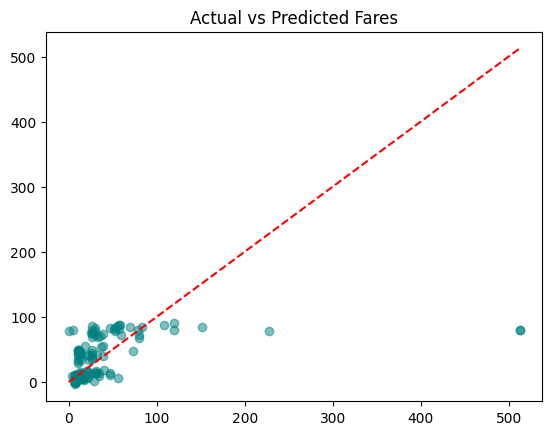

In [17]:
import matplotlib.pyplot as plt

# Plot actual fare values against model predicted values
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5, color='teal')

# Add a red dashed line representing perfect predictions
plt.plot([min(y_test_reg), max(y_test_reg)], [min(y_test_reg), max(y_test_reg)], 'r--')
plt.title('Actual vs Predicted Fares')
plt.show()


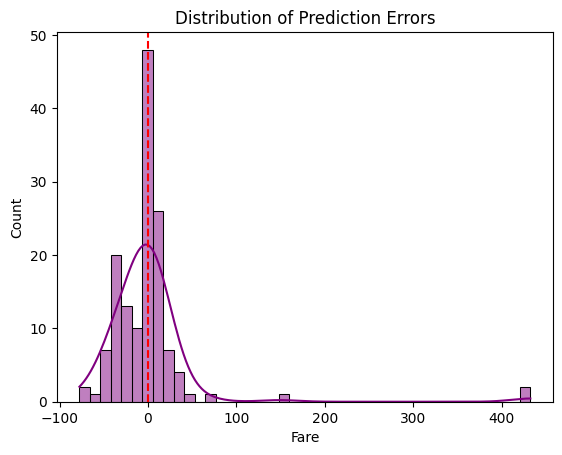

In [18]:
import seaborn as sns

# Calculate residuals and plot their distribution
residuals = y_test_reg - y_pred_reg
sns.histplot(residuals, kde=True, color='purple')

# Add a reference line at zero error to evaluate model bias
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Prediction Errors')
plt.show()


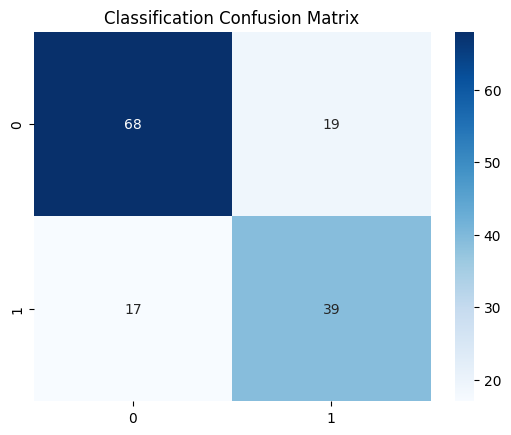

In [19]:
from sklearn.metrics import confusion_matrix

# Generate the performance matrix comparing true vs predicted labels
cm = confusion_matrix(y_test_cls, y_pred_cls)

# Display the matrix visually using a colored heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Classification Confusion Matrix')
plt.show()


### **Individual Contribution & Reflection**
As I am working completely independently on this lab as the sole member of group **ML_1371_12321_9**, I executed and completed 100% of the deliverables for this assignment.

* **My Core Contributions:** I successfully handled the complete data pipeline, including dropping missing data, mapping categorical variables to binary formats, fixing the environment script execution errors, training both the `LinearRegression` and `LogisticRegression` models, implementing the 3 diagnostic plotting experiments, and writing all theoretical analysis answers.
* **Key Insights & Takeaways:** Working solo allowed me to closely compare how regression handles continuous numerical metrics (like ticket fares where we measure distance using MSE) versus how classification deals with discrete, categorical labels (like survival rates evaluated using accuracy scores).
